# Phase 12: pegged-asset economics — defended bands, de-peg hazard, and derivatives

Computational record for `PHASE_12_PEG.md`. The project's exact
machinery assembled into a new domain:

1. **Defended band**: while credible, the log-mispricing is
   two-sided reflected Brownian motion; its stationary law is the
   exponential trapezoid \(\pi(y)\propto e^{2by/\sigma^2}\) — closed
   form.
2. **De-peg clock**: credibility is a bounded factor
   \(C_t=f(Z_t)\); de-peg at \(\tau=\inf\{t:C_t\ge c_*\}\). Every
   Milestone-1 law applies verbatim: hitting CDF, IG density,
   perpetual mass, and the pay-at-hit Laplace transform
   \(E[e^{-r\tau}]=\exp((\lambda-\sqrt{\lambda^2+2r/\sigma_z^2})\,
   \text{distance})\).
3. **Post-de-peg free float**: Gaussian continuation from the band
   edge; contingent payoffs reduce to one quadrature over the exact
   IG density (deterministic pricing of shortfall swaps).

In [1]:
from pathlib import Path
import json, math, platform, sys, time

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import scipy

ROOT = Path.cwd().resolve()
if not (ROOT / "phase12_peg.py").exists():
    candidates = [ROOT, *ROOT.parents]
    ROOT = next(p for p in candidates if (p / "phase12_peg.py").exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import phase12_peg as p12

SEED = 20260821
FIGURES = ROOT / "phase12_figures"
FIGURES.mkdir(exist_ok=True)

BAND = p12.BandSpec(lo=-0.02, hi=0.03)
PEG = p12.PegModel(lam=-0.25, sigma_z=0.9, scale=1.1,
                   rho0=0.3, rho_star=0.85, rate=0.05)

environment = {
    "python": platform.python_version(),
    "numpy": np.__version__,
    "scipy": scipy.__version__,
    "matplotlib": matplotlib.__version__,
    "platform": platform.platform(),
    "seed": SEED,
}
print(json.dumps(environment, indent=2))
started = time.time()

{
  "python": "3.12.13",
  "numpy": "2.5.1",
  "scipy": "1.18.0",
  "matplotlib": "3.11.1",
  "platform": "Linux-7.2.0-1-cachyos-x86_64-with-glibc2.44",
  "seed": 20260821
}


## 1. Defended-band stationary law

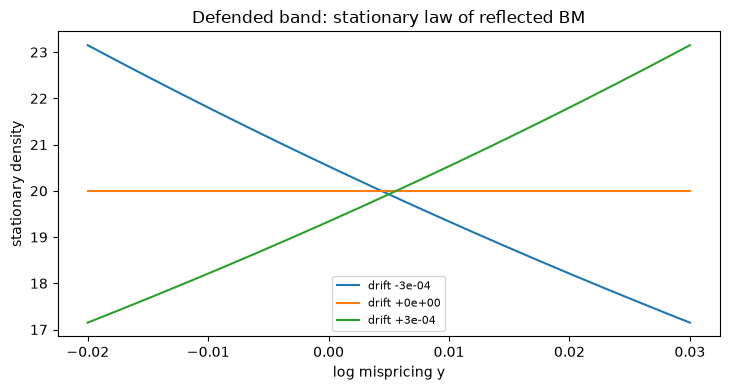

drift -3e-04: mean +0.00375  sd 0.01440
drift +0e+00: mean +0.00500  sd 0.01443
drift +3e-04: mean +0.00625  sd 0.01440


In [2]:
drifts = [-3e-4, 0.0, 3e-4]
grid = np.linspace(BAND.lo, BAND.hi, 300)
fig, ax = plt.subplots(figsize=(7.4, 4.0))
for b in drifts:
    dens = np.exp(2.0 * b * grid / 0.01**2)
    dens /= np.trapezoid(dens, grid)
    ax.plot(grid, dens, label=f"drift {b:+.0e}")
ax.set_xlabel("log mispricing y"); ax.set_ylabel("stationary density")
ax.set_title("Defended band: stationary law of reflected BM")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES / "phase12_band_stationary.png", dpi=150)
plt.show()

for b in drifts:
    stat = p12.reflected_band_stationary(BAND, drift=b, sigma=0.01)
    print(f"drift {b:+.0e}: mean {stat['mean']:+.5f}  sd {stat['sd']:.5f}")

## 2. The de-peg clock

Exact hitting CDF for three credibility-deterioration speeds
(\(\lambda<0\)), and the pay-at-hit Laplace transform as a function
of the discount rate.

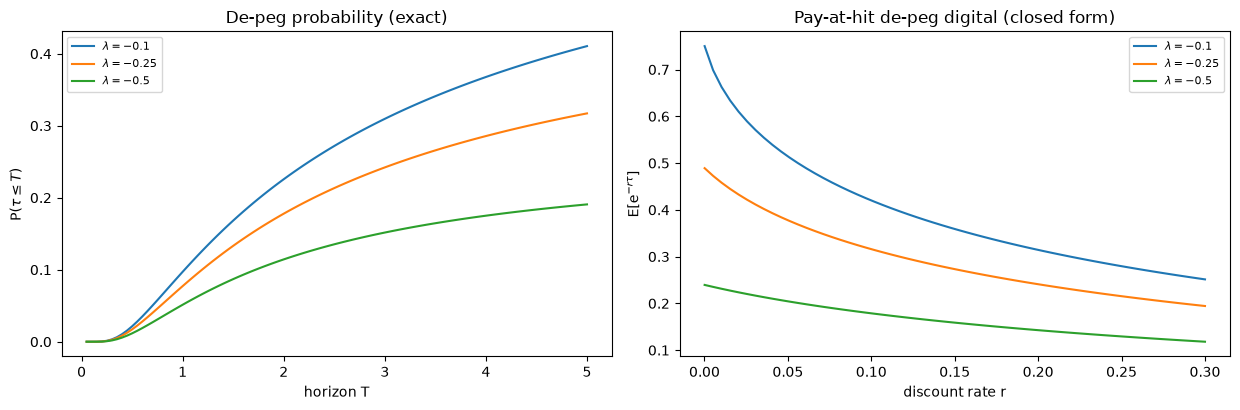

P(de-peg by 0.5) = 0.01714   digital = 0.01671
P(de-peg by 1.0) = 0.07726   digital = 0.07349
P(de-peg by 2.0) = 0.17785   digital = 0.16093
P(de-peg by 5.0) = 0.31713   digital = 0.24698
pay-at-hit E[e^(-r tau)] = 0.37777


In [3]:
horizons = np.linspace(0.05, 5.0, 100)
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2))
for lam in (-0.10, -0.25, -0.50):
    peg = p12.PegModel(lam=lam, sigma_z=0.9, scale=1.1,
                       rho0=0.3, rho_star=0.85, rate=0.05)
    cdfs = [peg.depeg_probability(float(h)) for h in horizons]
    axes[0].plot(horizons, cdfs, label=f"$\\lambda={lam}$")
    rs = np.linspace(1e-4, 0.30, 60)
    laps = []
    for r in rs:
        peg_r = p12.PegModel(lam=lam, sigma_z=0.9, scale=1.1,
                             rho0=0.3, rho_star=0.85, rate=float(r))
        laps.append(peg_r.pay_at_hit_laplace())
    axes[1].plot(rs, laps, label=f"$\\lambda={lam}$")
axes[0].set_xlabel("horizon T"); axes[0].set_ylabel(r"P($\tau\leq T$)")
axes[0].set_title("De-peg probability (exact)")
axes[0].legend(fontsize=8)
axes[1].set_xlabel("discount rate r"); axes[1].set_ylabel(r"E[e$^{-r\tau}$]")
axes[1].set_title("Pay-at-hit de-peg digital (closed form)")
axes[1].legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES / "phase12_hazard.png", dpi=150)
plt.show()

for horizon in (0.5, 1.0, 2.0, 5.0):
    print(f"P(de-peg by {horizon}) = {PEG.depeg_probability(horizon):.5f}"
          f"   digital = {PEG.depeg_digital(horizon):.5f}")
print(f"pay-at-hit E[e^(-r tau)] = {PEG.pay_at_hit_laplace():.5f}")

## 3. Shortfall swap: deterministic pricing vs simulation

Pays \((K-P_T)^+\) with \(K\) a fraction of parity (price
\(P_T=e^{\log P_T}\)) only if the peg breaks by \(T\). Price = one
quadrature over the exact IG density of \(\tau\) times closed-form
Gaussian components.

K=0.70: shortfall swap = 0.004430
K=0.80: shortfall swap = 0.008631
K=0.90: shortfall swap = 0.014859
K=0.95: shortfall swap = 0.018850
K=0.98: shortfall swap = 0.021529



simulation de-peg freq 0.17800 vs exact 0.17785 (0.00086)
simulation frac(logP<0): 0.42627


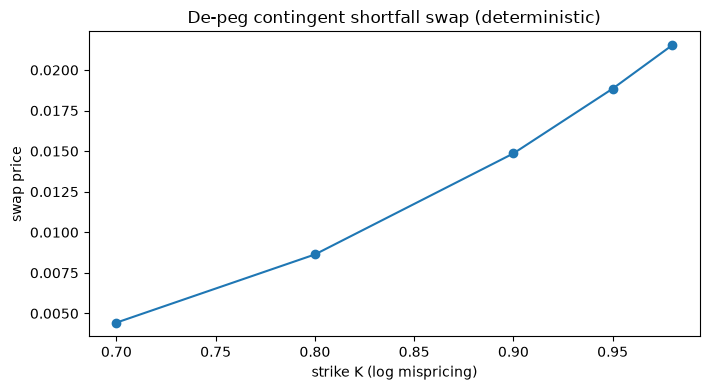

In [4]:
strikes = [0.70, 0.80, 0.90, 0.95, 0.98]
prices = [
    PEG.shortfall_swap(k, horizon=2.0, band=BAND,
                       mu_free=-0.15, sigma_free=0.35)
    for k in strikes
]
for k, v in zip(strikes, prices):
    print(f"K={k:.2f}: shortfall swap = {v:.6f}")

res = p12.simulate_peg_paths(
    band=BAND, drift_band=0.0, sigma_band=0.008, peg=PEG,
    horizon=2.0, mu_free=-0.15, sigma_free=0.35,
    n_paths=200000, n_steps=250, seed=SEED)
exact_freq = PEG.depeg_probability(2.0)
se = math.sqrt(exact_freq * (1 - exact_freq) / 200000)
print(f"\nsimulation de-peg freq {res['depeg_freq']:.5f} vs exact "
      f"{exact_freq:.5f} ({se:.5f})")
print(f"simulation frac(logP<0): {res['frac_below_zero']:.5f}")

fig, ax = plt.subplots(figsize=(7.2, 4.0))
ax.plot(strikes, prices, "o-")
ax.set_xlabel("strike K (log mispricing)"); ax.set_ylabel("swap price")
ax.set_title("De-peg contingent shortfall swap (deterministic)")
fig.tight_layout()
fig.savefig(FIGURES / "phase12_shortfall.png", dpi=150)
plt.show()

## 4. Record

All prices are closed form or single quadratures over exact laws;
simulation only benchmarks. Figures in `phase12_figures/`.

In [5]:
elapsed = time.time() - started
print(f"notebook executed in {elapsed:.1f} s")

notebook executed in 1.2 s
